# 03 — Exploratory Data Analysis (EDA)
**Project:** Telco Customer Churn Prediction  
**Author:** Udit Jadli  
**Dataset:** Maven Analytics — Telecom Customer Churn  

## Objective
Visually explore the dataset to understand distributions, identify patterns, 
and uncover relationships between features and churn — before building any ML models.

## 1. Imports
We import all libraries needed for data manipulation and visualisation in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# setting plot styles globally so all charts in this notebook, so it looks consistent
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)   # default chart size for all plots
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.labelsize']  = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data
We reload the cleaned dataset from the raw CSV file. We also recreate the binary 
`Churn` column that we will use throughout this notebook as our target variable.

In [2]:
# define file path
DATA_RAW = os.path.join('..', 'data', 'raw')

# load main churn table
df = pd.read_csv(os.path.join(DATA_RAW, 'telecom_customer_churn.csv'), encoding='latin-1')

# recreate binary churn column — 1 = churned, 0 = stayed or joined
df['Churn'] = (df['Customer Status'] == 'Churned').astype(int)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate: {df['Churn'].mean() * 100:.1f}%")

Dataset loaded: 7,043 rows × 39 columns
Churn rate: 26.5%


## 3. Churn Distribution
We visualise the overall distribution of our target variable to understand 
the class balance before any modelling.

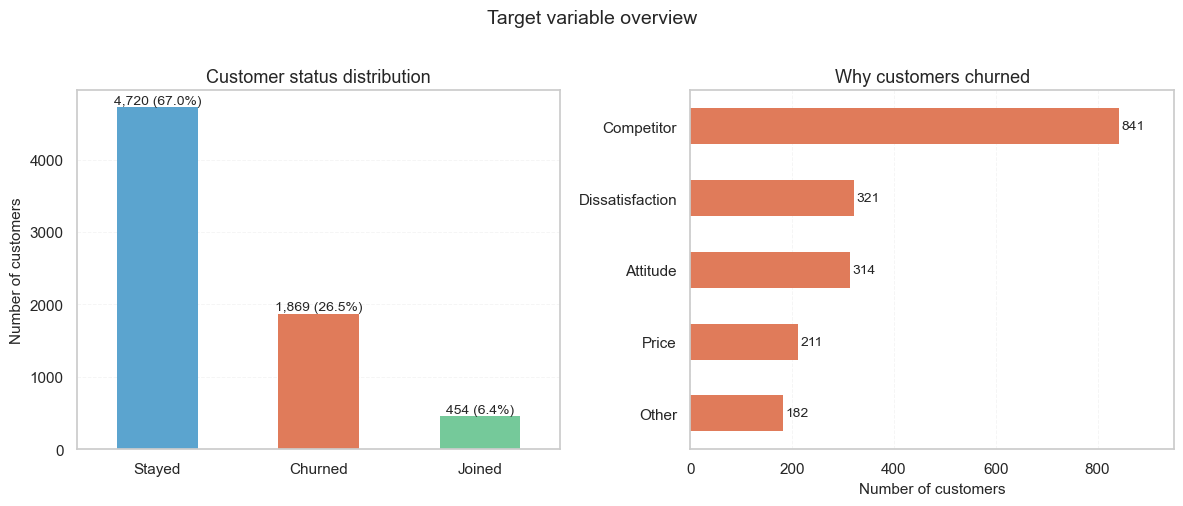

Saved → reports/figures/03_churn_distribution.png


In [3]:
# calculate counts and percentages — defined here so cell is self-contained
status_counts = df['Customer Status'].value_counts()
status_pct    = (status_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left chart
colors = ['#5BA4CF', '#E07B5A', '#75C99A']
status_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='none', rot=0)
axes[0].set_title('Customer status distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of customers')
axes[0].set_axisbelow(True)
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[0].xaxis.grid(False)
for bar in axes[0].patches:
    height = bar.get_height()
    pct = height / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 height + 50,
                 f'{int(height):,} ({pct:.1f}%)',
                 ha='center', fontsize=10)

# right chart
churn_cat = df[df['Churn'] == 1]['Churn Category'].value_counts()
churn_cat.plot(kind='barh', ax=axes[1], color='#E07B5A', edgecolor='none')
axes[1].set_title('Why customers churned')
axes[1].set_xlabel('Number of customers')
axes[1].set_ylabel('')
axes[1].invert_yaxis()
axes[1].set_axisbelow(True)
axes[1].xaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[1].yaxis.grid(False)
axes[1].set_xlim(0, 950)
for bar in axes[1].patches:
    width = bar.get_width()
    axes[1].text(width + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(width):,}', va='center', fontsize=10)

plt.suptitle('Target variable overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/03_churn_distribution.png")

**Finding:** 26.5% of customers churned in Q2 2022. Competitor advantages 
are the dominant churn driver (841 customers), followed by dissatisfaction 
and attitude issues — both of which are within the company's control to address.

## 4. Churn Rate by Key Categories
We compare churn rates across the most important categorical variables 
to identify which customer segments are at highest risk.

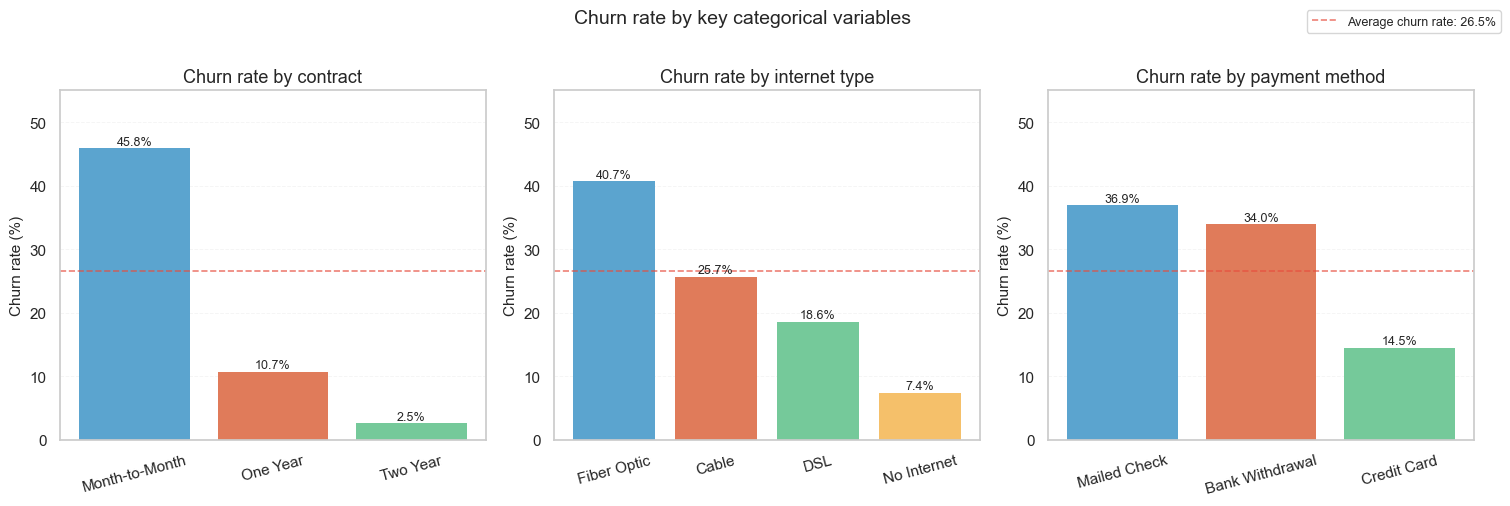

Saved → reports/figures/03_churn_by_category.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cat_cols = ['Contract', 'Internet Type', 'Payment Method']
colors   = ['#5BA4CF', '#E07B5A', '#75C99A', '#F5C06A']
baseline = df['Churn'].mean() * 100  # overall churn rate — 26.5%

for i, col in enumerate(cat_cols):
    # fill missing internet type with 'No Internet' before calculating churn rate
    temp = df.copy()
    temp[col] = temp[col].fillna('No Internet')

    churn_rate = temp.groupby(col)['Churn'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False)

    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=colors[:len(churn_rate)], edgecolor='none')

    # baseline reference line — no label here, added once via fig.legend below
    axes[i].axhline(y=baseline, color='#E74C3C', linestyle='--',
                    linewidth=1.2, alpha=0.7)

    axes[i].set_title(f'Churn rate by {col.lower()}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 55)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_axisbelow(True)
    axes[i].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
    axes[i].xaxis.grid(False)

    # percentage labels on top of each bar
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%',
                     ha='center', fontsize=9)

# single legend for the baseline line — shown once at figure level
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='#E74C3C', linestyle='--',
                           linewidth=1.2, alpha=0.7,
                           label=f'Average churn rate: {baseline:.1f}%')]
fig.legend(handles=legend_elements, loc='upper right',
           bbox_to_anchor=(1.01, 1.02), fontsize=9)

plt.suptitle('Churn rate by key categorical variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/03_churn_by_category.png")

**Finding:** Contract type shows the strongest churn signal — Month-to-Month 
customers churn at 45.8%, nearly 18x higher than Two Year customers (2.5%). 
Fiber Optic customers churn at 40.7% despite being the premium service. 
Credit Card payment is associated with the lowest churn at 14.5%.

## 5. Tenure Distribution by Churn
We examine how customer tenure differs between churned and non-churned customers 
to identify the critical retention window.

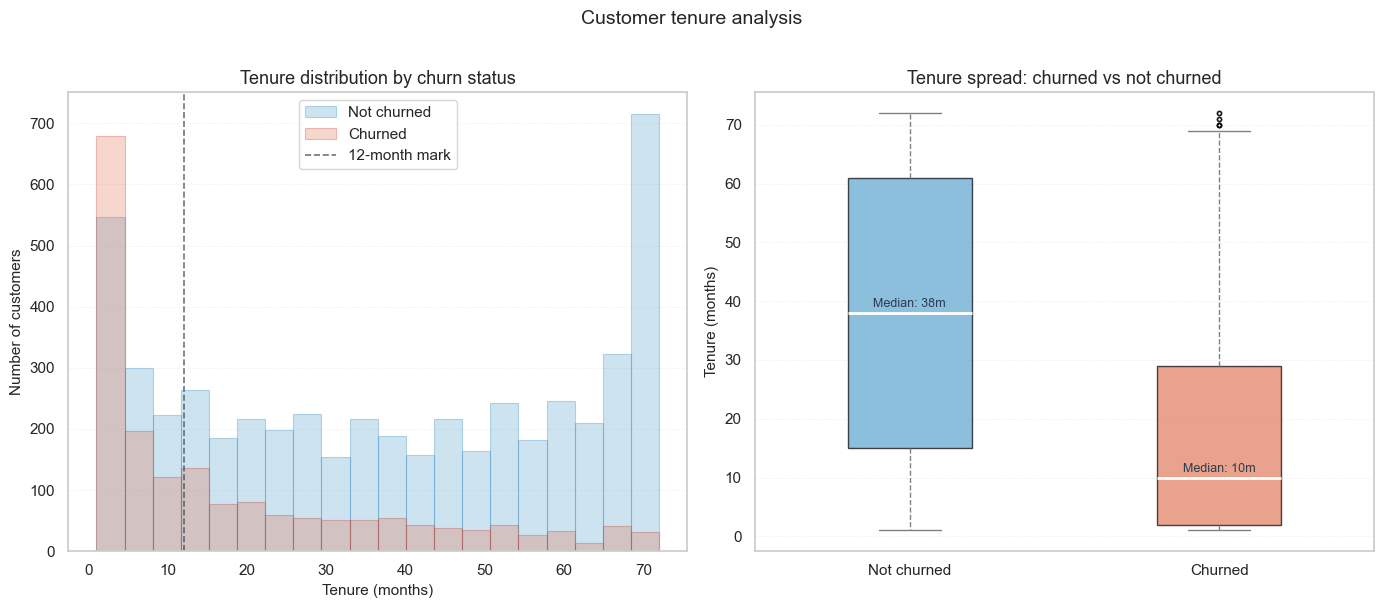

Saved → reports/figures/03_tenure_analysis.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

not_churned_tenure = df[df['Churn'] == 0]['Tenure in Months']
churned_tenure     = df[df['Churn'] == 1]['Tenure in Months']

# left — histogram with bold coloured edges
axes[0].hist(not_churned_tenure, bins=20, alpha=0.3,
             color='#5BA4CF', edgecolor='#2980B9', linewidth=0.8, label='Not churned')
axes[0].hist(churned_tenure, bins=20, alpha=0.3,
             color='#E07B5A', edgecolor='#C0392B', linewidth=0.8, label='Churned')
axes[0].axvline(x=12, color='#2C3E50', linestyle='--',
                linewidth=1.2, alpha=0.7, label='12-month mark')
axes[0].set_title('Tenure distribution by churn status')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of customers')
axes[0].legend()
axes[0].set_axisbelow(True)
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[0].xaxis.grid(False)

# right — box plot showing full distribution, not just average
churn_labels = {0: 'Not churned', 1: 'Churned'}
data_to_plot = [not_churned_tenure, churned_tenure]

bp = axes[1].boxplot(data_to_plot,
                     patch_artist=True,   # fills boxes with colour
                     widths=0.4,
                     medianprops=dict(color='white', linewidth=2))

# colour each box
box_colors = ['#5BA4CF', '#E07B5A']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# style whiskers and caps
for whisker in bp['whiskers']:
    whisker.set(color='gray', linewidth=1, linestyle='--')
for cap in bp['caps']:
    cap.set(color='gray', linewidth=1)
for flier in bp['fliers']:
    flier.set(marker='o', color='gray', alpha=0.3, markersize=3)

axes[1].set_title('Tenure spread: churned vs not churned')
axes[1].set_ylabel('Tenure (months)')
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Not churned', 'Churned'])
axes[1].set_axisbelow(True)
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[1].xaxis.grid(False)

# add median labels above each box
for i, data in enumerate(data_to_plot):
    median = data.median()
    axes[1].text(i + 1, median + 1, f'Median: {median:.0f}m',
                 ha='center', fontsize=9, color='#2C3E50')

plt.suptitle('Customer tenure analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/03_tenure_analysis.png")

**Finding:** Churned customers have a median tenure of just 10 months compared 
to 38 months for non-churned customers. The box plot confirms churn is heavily 
concentrated in the early months — the first year is the critical retention window. 
Customers who survive past 30 months rarely churn.

## 6. Monthly Charge Distribution
We compare monthly charge distributions between churned and non-churned customers. 
The dotted lines inside each violin represent the 25th percentile, median, and 
75th percentile of monthly charges.

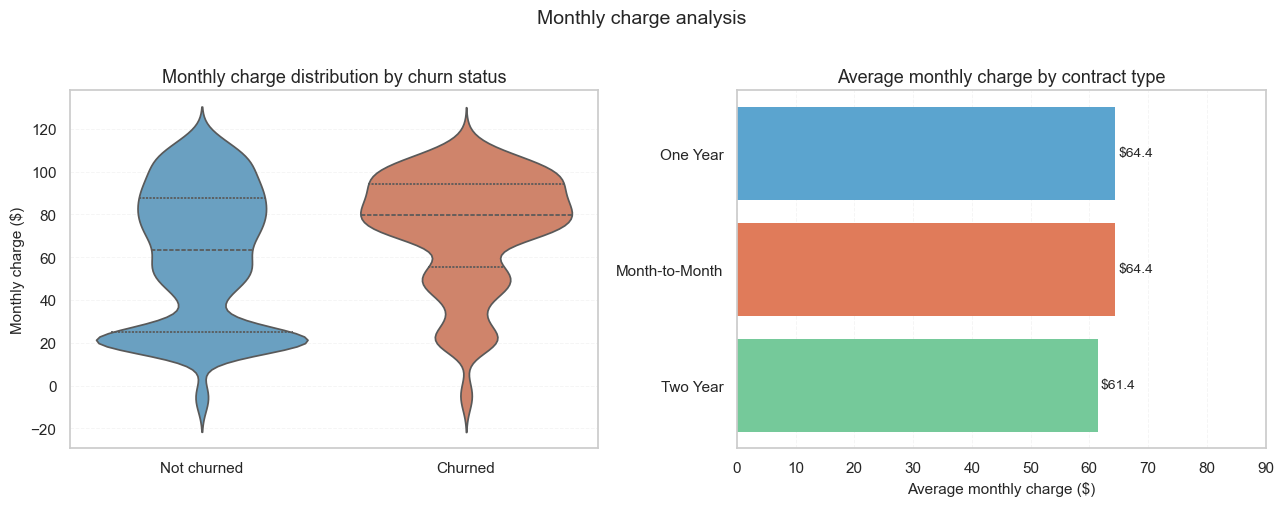

Saved → reports/figures/03_monthly_charge.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left — violin plot
sns.violinplot(data=df, x='Churn', y='Monthly Charge',
               palette={'0': '#5BA4CF', '1': '#E07B5A'},
               inner='quartile',
               ax=axes[0])
axes[0].set_title('Monthly charge distribution by churn status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monthly charge ($)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not churned', 'Churned'])
axes[0].set_axisbelow(True)
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[0].xaxis.grid(False)

# right — horizontal bar chart
avg_charge = df.groupby('Contract')['Monthly Charge'].mean().sort_values()
bars = axes[1].barh(avg_charge.index, avg_charge.values,
                    color=['#75C99A', '#E07B5A', '#5BA4CF'], edgecolor='none')
axes[1].set_title('Average monthly charge by contract type')
axes[1].set_xlabel('Average monthly charge ($)')
axes[1].set_ylabel('')
axes[1].set_axisbelow(True)
axes[1].xaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[1].yaxis.grid(False)
axes[1].set_xlim(0, 90)
for bar in bars:
    axes[1].text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():.1f}',
                 va='center', fontsize=10)

plt.suptitle('Monthly charge analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/03_monthly_charge.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/03_monthly_charge.png")

**Finding:** Churned customers are concentrated at high monthly charges ($80-95) 
while non-churned customers show a bimodal distribution — spread across both low 
($20) and high ($85) charge ranges. Notably, One Year and Month-to-Month contracts 
have identical average charges ($64.4) — meaning price alone doesn't explain the 
18x difference in churn rates between those two contract types.

## 7. Correlation Heatmap
We examine how numeric features correlate with each other and with churn. 
Strong correlations help us identify which features will be most useful 
for our ML models and which may be redundant.

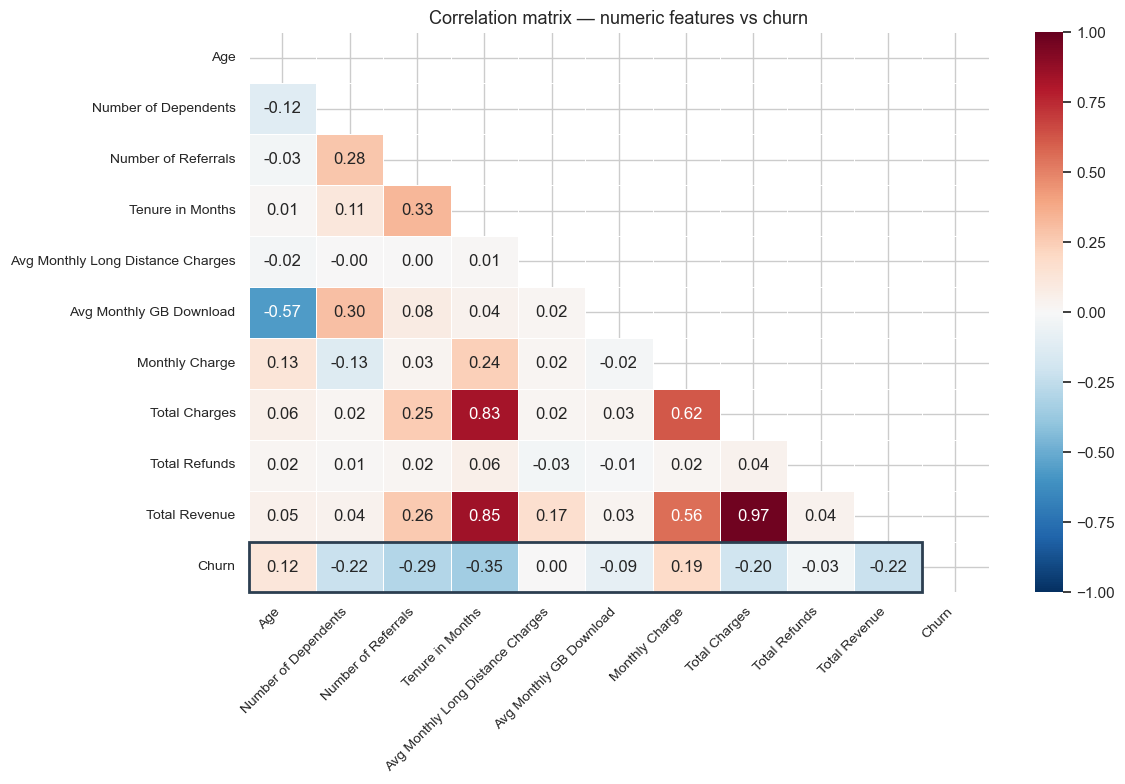

Saved → reports/figures/03_correlation_heatmap.png


In [7]:
# select numeric columns relevant for correlation analysis
numeric_cols = [
    'Age', 'Number of Dependents', 'Number of Referrals',
    'Tenure in Months', 'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download', 'Monthly Charge',
    'Total Charges', 'Total Refunds', 'Total Revenue', 'Churn'
]

# compute correlation matrix
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 8))

# mask upper triangle to avoid duplication
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            linecolor='white',
            ax=ax)

# rotate x-axis labels to 45 degrees for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# highlight the Churn row — it's the most important row in this matrix
churn_row_idx = numeric_cols.index('Churn')
ax.add_patch(plt.Rectangle(
    (0, churn_row_idx),         # bottom left corner
    churn_row_idx,               # width — only covers the filled cells
    1,                           # height of one row
    fill=False,
    edgecolor='#2C3E50',
    linewidth=2,
    clip_on=False
))

ax.set_title('Correlation matrix — numeric features vs churn', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/03_correlation_heatmap.png")

**Finding:** Tenure in Months has the strongest correlation with churn (-0.35) — 
confirming it as the most important numeric predictor. Number of Referrals (-0.29) 
is the second strongest — loyal customers actively refer others. Monthly Charge 
shows a mild positive correlation (0.19) — higher-paying customers churn slightly 
more. Note: Total Charges and Total Revenue are highly correlated with each other 
(0.97) — we will handle this multicollinearity in the feature engineering notebook.

## 8. Churn Rate by Age Group
We examine whether age influences churn behaviour by grouping customers 
into age bands and comparing churn rates across each group.

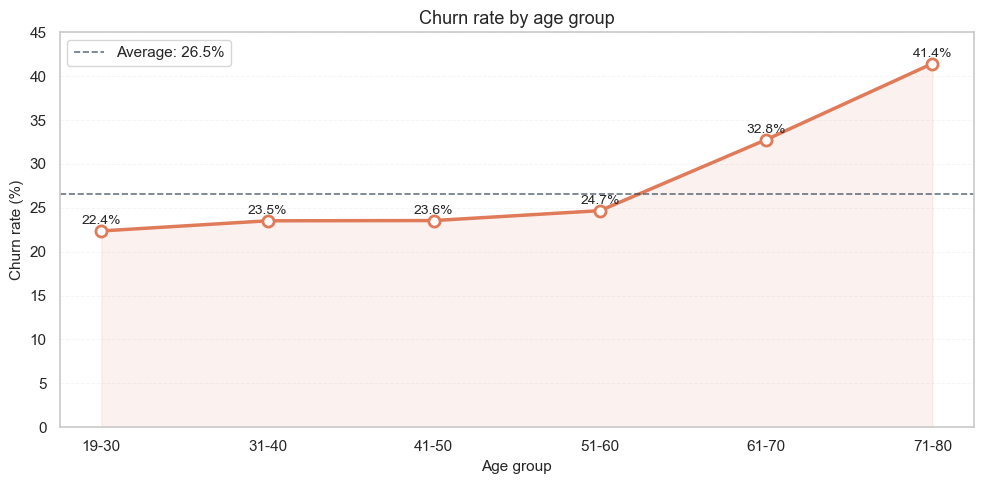

Saved → reports/figures/03_churn_by_age.png


In [8]:
# create age groups in 10-year bands
df['Age Group'] = pd.cut(df['Age'],
                          bins=[18, 30, 40, 50, 60, 70, 80],
                          labels=['19-30', '31-40', '41-50', '51-60', '61-70', '71-80'])

# calculate churn rate per age group
age_churn = df.groupby('Age Group', observed=True)['Churn'].mean() * 100
baseline  = df['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(age_churn))

# shade area under the line — subtle background fill
ax.fill_between(x, age_churn.values, alpha=0.1, color='#E07B5A')

# line chart with markers
ax.plot(x, age_churn.values,
        color='#E07B5A', linewidth=2.5,
        marker='o', markersize=8, markerfacecolor='white',
        markeredgecolor='#E07B5A', markeredgewidth=2)

# baseline reference line
ax.axhline(y=baseline, color='#2C3E50', linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'Average: {baseline:.1f}%')

# value labels above each point
for i, (age, rate) in enumerate(zip(age_churn.index, age_churn.values)):
    ax.text(i, rate + 0.8, f'{rate:.1f}%', ha='center', fontsize=10)

ax.set_title('Churn rate by age group')
ax.set_xlabel('Age group')
ax.set_ylabel('Churn rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(age_churn.index)
ax.set_ylim(0, 45)
ax.legend()
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
ax.xaxis.grid(False)

plt.tight_layout()
plt.savefig('../reports/figures/03_churn_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/03_churn_by_age.png")

**Finding:** Churn rate increases sharply with age — customers aged 61-70 churn 
at 32.8% and 71-80 at 41.4%, well above the 26.5% average. Younger customers 
(19-50) are actually below average risk. This suggests older customers may be 
more susceptible to competitor offers or less satisfied with digital-first services.